In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load data
monthly_activity_df = pd.read_csv('../data/synthetic/monthly_activity.csv')

#inspect data
print(monthly_activity_df.shape)
monthly_activity_df.head()
monthly_activity_df.info()
monthly_activity_df.describe(include='all')

#check nulls
null_summary = pd.DataFrame({
    'nulls': monthly_activity_df.isnull().sum(),
    'pct':   (monthly_activity_df.isnull().sum() / len(monthly_activity_df) * 100).round(2)
})
print(null_summary[null_summary['nulls'] > 0])

(121524, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121524 entries, 0 to 121523
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   customer_id        121524 non-null  int64  
 1   month              121524 non-null  int64  
 2   txn_count          121524 non-null  int64  
 3   txn_amount         121524 non-null  float64
 4   login_count        121524 non-null  int64  
 5   support_contacts   121524 non-null  int64  
 6   utilization_ratio  121524 non-null  float64
 7   churn_start_month  19524 non-null   float64
 8   final_decay        19524 non-null   float64
 9   churned_flag       121524 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 9.3 MB
                    nulls    pct
churn_start_month  102000  83.93
final_decay        102000  83.93


In [39]:
# consistent style across all charts
plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'figure.dpi':        150,
})

CHURN_COLOR    = '#E05A3A'
RETAIN_COLOR   = '#534AB7'
NEUTRAL_COLOR  = '#3BAA82'


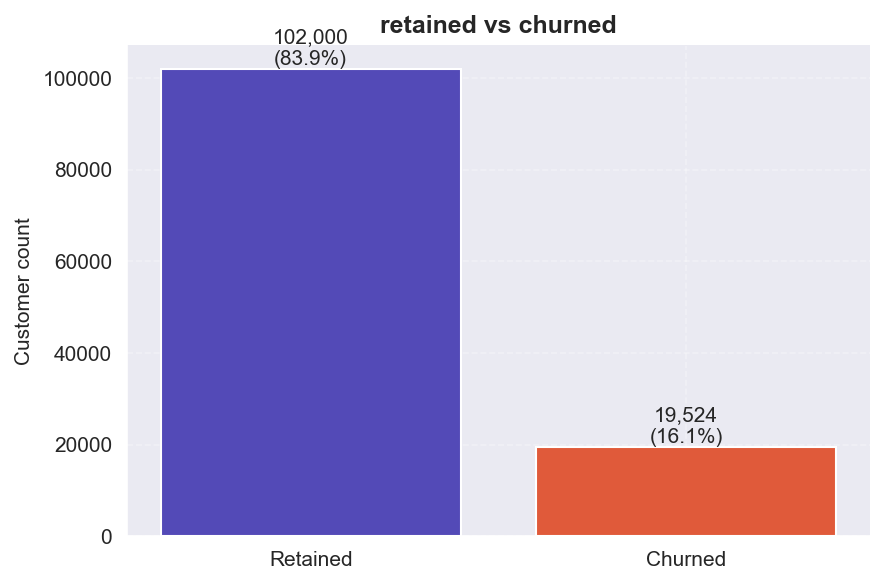

In [49]:
# vis 1 - retained vs churned
churn_counts = monthly_activity_df['churned_flag'].value_counts()
churn_pct    = monthly_activity_df['churned_flag'].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Retained', 'Churned'], churn_counts.values, color=[RETAIN_COLOR, CHURN_COLOR])
ax.bar_label(bars, labels=[f"{v:,}\n({p:.1f}%)" for v, p in zip(churn_counts.values, churn_pct.values)], padding=0)
ax.set_title('retained vs churned', fontweight='bold')
ax.set_ylabel('Customer count')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../visualization/eda_class_balance.png', dpi=150)
plt.show()


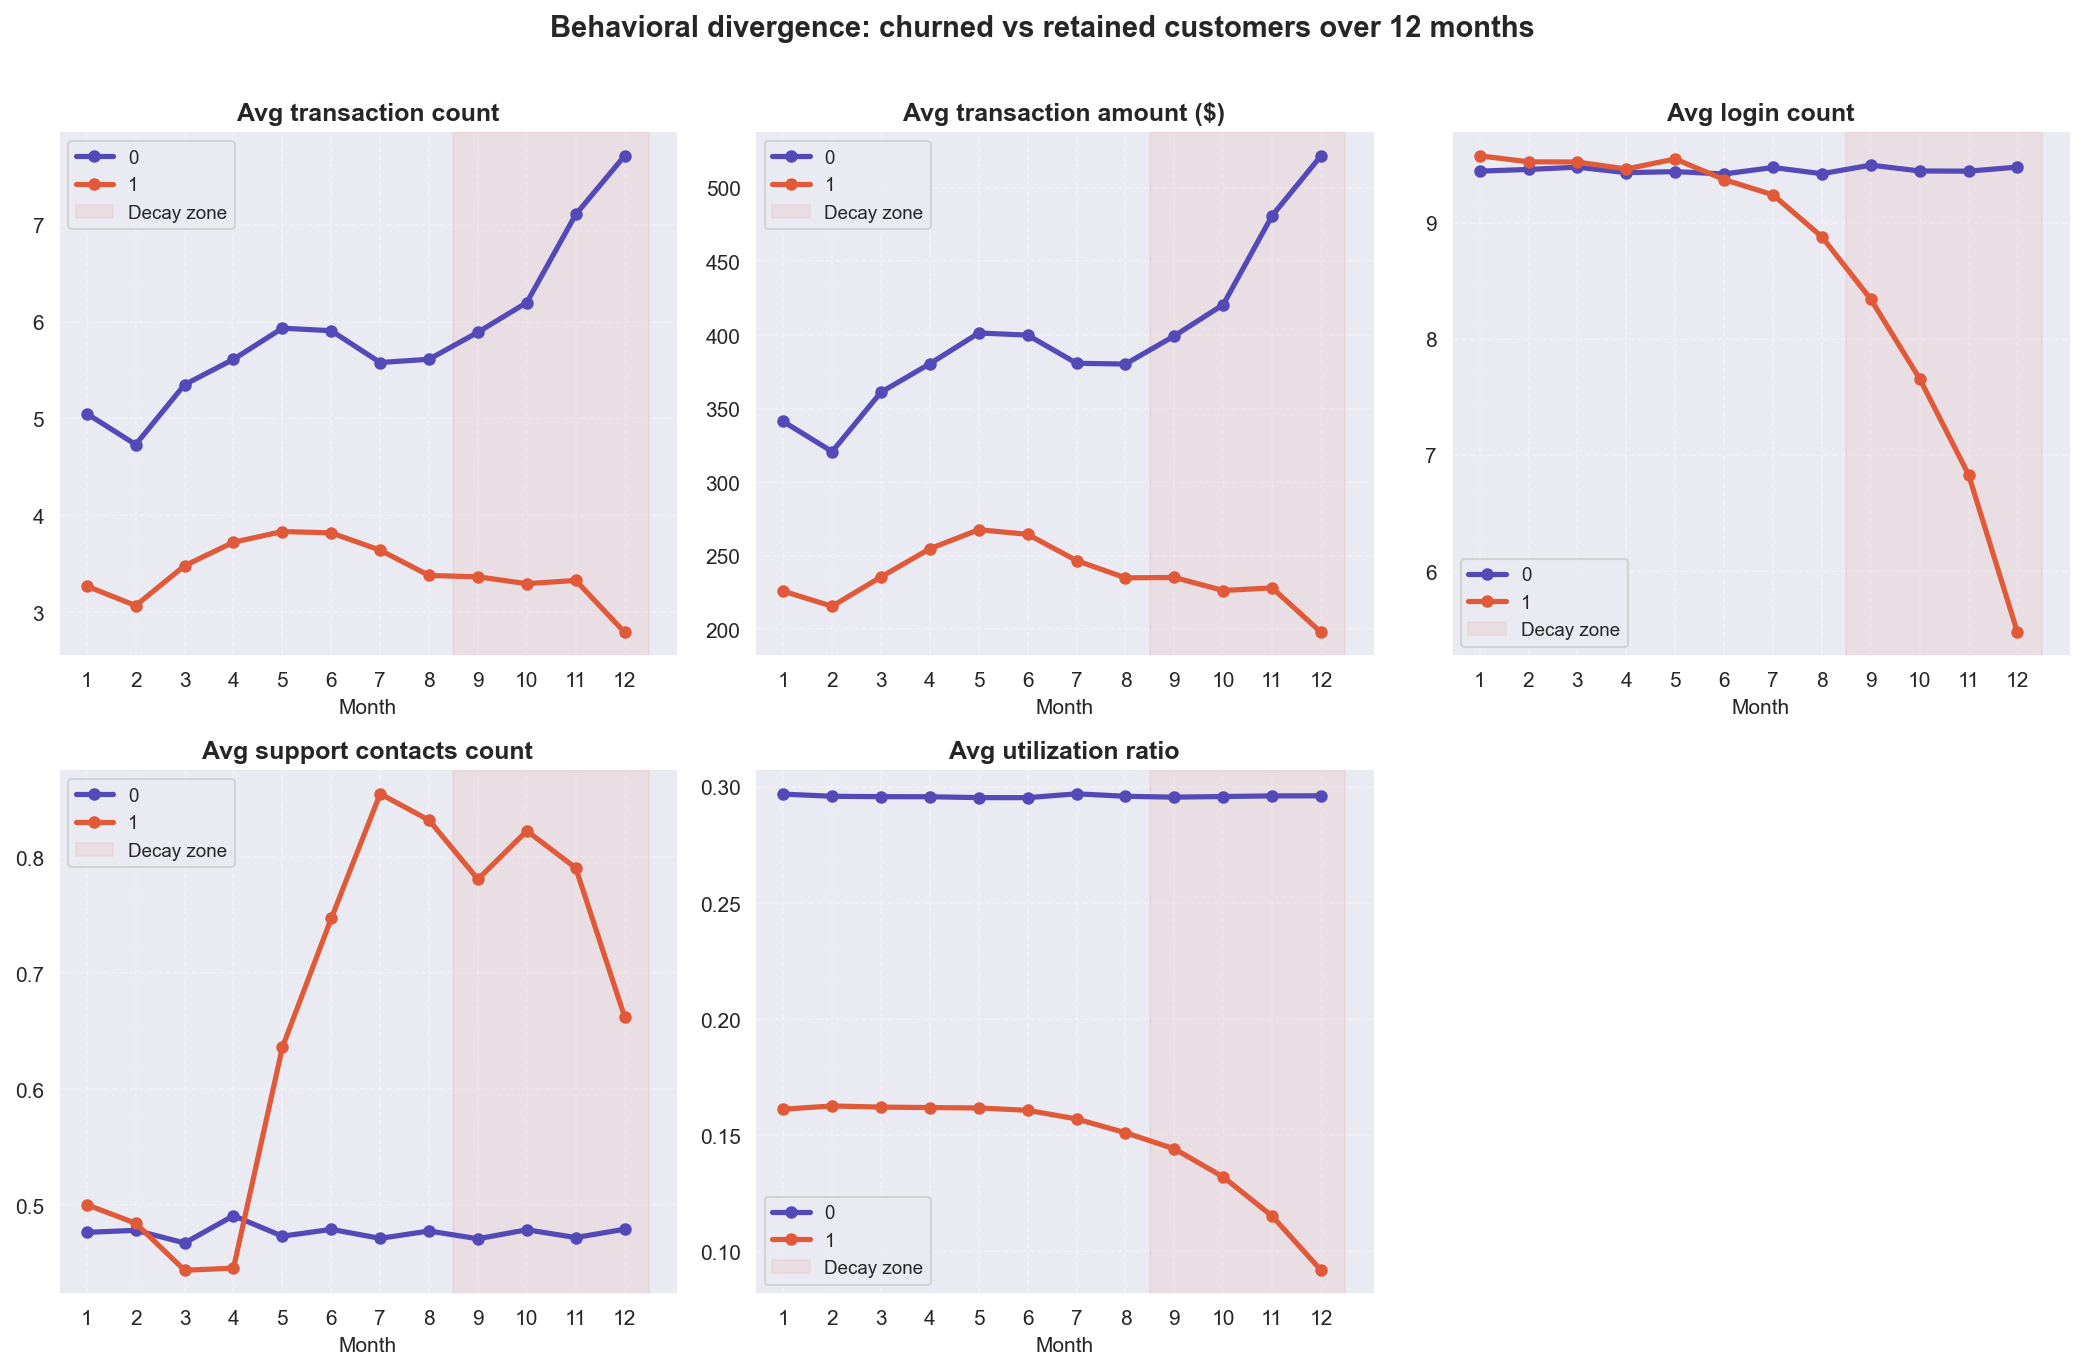

In [48]:
#vis 2 - line chart of avg metrics over time, churned vs retained
metrics = {
            'txn_count':        'Avg transaction count',
            'txn_amount':       'Avg transaction amount ($)',
            'login_count':      'Avg login count',
            'support_contacts': 'Avg support contacts count',
            'utilization_ratio':'Avg utilization ratio',
            }
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()
axes[5].set_visible(False)  # hide the empty 6th slot
for i, (col, label) in enumerate(metrics.items()):
    monthly_avg = (
        monthly_activity_df.groupby(['month', 'churned_flag'])[col]
        .mean()
        .reset_index()
    )

    for churn_label, color in [(0, RETAIN_COLOR), (1, CHURN_COLOR)]:
        data = monthly_avg[monthly_avg['churned_flag'] == churn_label]
        axes[i].plot(
            data['month'], data[col],
            marker='o', color=color,
            label=churn_label, linewidth=2.5, markersize=5
        )

    # shade the last 4 months
    axes[i].axvspan(8.5, 12.5, alpha=0.08, color=CHURN_COLOR, label='Decay zone')

    axes[i].set_title(label, fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Month')
    axes[i].set_xticks(range(1, 13))
    axes[i].legend(fontsize=9)

plt.suptitle(
    'Behavioral divergence: churned vs retained customers over 12 months',
    fontweight='bold', fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig('../visualization/viz1_line_avrgs_churned_vs_retained.png', dpi=150, bbox_inches='tight')
plt.show()